<a href="https://colab.research.google.com/github/akithmaaponso7-spec/northstaranalytics/blob/main/Python_Data_Processing_%26_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving northstar_dataset.zip to northstar_dataset.zip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

In [4]:
zip_file = "northstar_dataset.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("northstar_dataset")

print("Dataset extracted successfully")

Dataset extracted successfully


In [5]:
for root, dirs, files in os.walk("northstar_dataset"):
    for file in files:
        print(os.path.join(root, file))

northstar_dataset/northstar_dataset/deliveries.csv
northstar_dataset/northstar_dataset/orders.csv
northstar_dataset/northstar_dataset/hubs.csv
northstar_dataset/northstar_dataset/customers.csv
northstar_dataset/northstar_dataset/app_events.csv
northstar_dataset/northstar_dataset/data_dictionary.csv
northstar_dataset/northstar_dataset/complaints.csv
northstar_dataset/northstar_dataset/incidents.csv
northstar_dataset/northstar_dataset/vehicles.csv
northstar_dataset/northstar_dataset/README.txt
northstar_dataset/northstar_dataset/drivers.csv


In [6]:
csv_files = {}

for root, dirs, files in os.walk("northstar_dataset"):
    for file in files:
        if file.endswith(".csv"):
            file_path = os.path.join(root, file)
            csv_files[file.replace(".csv", "")] = file_path

csv_files

{'deliveries': 'northstar_dataset/northstar_dataset/deliveries.csv',
 'orders': 'northstar_dataset/northstar_dataset/orders.csv',
 'hubs': 'northstar_dataset/northstar_dataset/hubs.csv',
 'customers': 'northstar_dataset/northstar_dataset/customers.csv',
 'app_events': 'northstar_dataset/northstar_dataset/app_events.csv',
 'data_dictionary': 'northstar_dataset/northstar_dataset/data_dictionary.csv',
 'complaints': 'northstar_dataset/northstar_dataset/complaints.csv',
 'incidents': 'northstar_dataset/northstar_dataset/incidents.csv',
 'vehicles': 'northstar_dataset/northstar_dataset/vehicles.csv',
 'drivers': 'northstar_dataset/northstar_dataset/drivers.csv'}

In [7]:
customers = pd.read_csv(csv_files["customers"])
orders = pd.read_csv(csv_files["orders"])
deliveries = pd.read_csv(csv_files["deliveries"])
drivers = pd.read_csv(csv_files["drivers"])
vehicles = pd.read_csv(csv_files["vehicles"])
hubs = pd.read_csv(csv_files["hubs"])
complaints = pd.read_csv(csv_files["complaints"])
incidents = pd.read_csv(csv_files["incidents"])
app_events = pd.read_csv(csv_files["app_events"])

print("All datasets loaded successfully")

All datasets loaded successfully


In [8]:
customers.head()

,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
1,C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
2,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NaN,Active
3,C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
4,C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active


In [9]:
deliveries.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22


In [10]:
complaints.head()

,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
0,CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
1,CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
2,CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41
3,CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44
4,CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18


In [11]:
datasets = {
    "customers": customers,
    "orders": orders,
    "deliveries": deliveries,
    "drivers": drivers,
    "vehicles": vehicles,
    "hubs": hubs,
    "complaints": complaints,
    "incidents": incidents,
    "app_events": app_events
}

for name, df in datasets.items():
    print(name, df.shape)

customers (650, 9)
orders (1250, 11)
deliveries (950, 13)
drivers (170, 8)
vehicles (120, 8)
hubs (8, 5)
complaints (320, 10)
incidents (280, 7)
app_events (640, 10)


In [12]:
for name, df in datasets.items():
    print("\nMissing values in", name)
    print(df.isnull().sum())


Missing values in customers
customer_id              0
age                      0
home_zone                0
customer_type            0
signup_date              0
loyalty_score           20
app_engagement_score     0
preferred_channel       13
account_status           0
dtype: int64

Missing values in orders
order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64

Missing values in deliveries
delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_o

In [13]:
for name, df in datasets.items():
    before = df.shape[0]
    df.drop_duplicates(inplace=True)
    after = df.shape[0]
    print(name, "duplicates removed:", before - after)

customers duplicates removed: 0
orders duplicates removed: 0
deliveries duplicates removed: 0
drivers duplicates removed: 0
vehicles duplicates removed: 0
hubs duplicates removed: 0
complaints duplicates removed: 0
incidents duplicates removed: 0
app_events duplicates removed: 0


In [14]:
deliveries.describe()

,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
count,950.000000,950.000000,950.000000,936.000000,950.000000
mean,13.909316,0.969474,0.072632,3.864679,12.841295
std,7.477907,1.093189,0.259667,0.894420,4.336468
min,1.200000,0.000000,0.000000,1.000000,2.500000
25%,9.135000,0.000000,0.000000,3.360000,9.925000
50%,12.840000,1.000000,0.000000,4.040000,12.645000
75%,16.835000,2.000000,0.000000,4.550000,15.697500
max,41.940000,7.000000,1.000000,5.000000,29.430000


In [15]:
customers.describe()

,age,loyalty_score,app_engagement_score
count,650.000000,630.000000,650.000000
mean,46.738462,59.690635,58.132308
std,17.449179,16.124674,18.918154
min,18.000000,13.100000,1.000000
25%,32.000000,49.000000,45.375000
50%,46.000000,59.600000,59.000000
75%,62.000000,70.450000,72.000000
max,78.000000,99.000000,100.000000


In [16]:
drivers.describe()

,years_experience,training_score,driver_rating,active_flag
count,170.000000,163.000000,170.000000,170.000000
mean,8.223529,74.914724,4.171706,0.947059
std,4.114850,11.213827,0.406301,0.224578
min,1.000000,40.600000,3.150000,0.000000
25%,5.000000,68.550000,3.905000,1.000000
50%,8.500000,75.200000,4.175000,1.000000
75%,11.750000,82.750000,4.477500,1.000000
max,15.000000,99.000000,5.000000,1.000000


In [17]:
deliveries["is_problem_delivery"] = np.where(
    deliveries["delivery_status"] != "Completed",
    1,
    0
)

deliveries[["delivery_status", "is_problem_delivery"]].head()

,delivery_status,is_problem_delivery
0,Failed,1
1,OnTime,1
2,OnTime,1
3,Delayed,1
4,OnTime,1


In [18]:
def rating_category(rating):
    if rating >= 4:
        return "High"
    elif rating >= 3:
        return "Medium"
    else:
        return "Low"

deliveries["rating_category"] = deliveries["customer_rating_post_delivery"].apply(rating_category)

deliveries[["customer_rating_post_delivery", "rating_category"]].head()

,customer_rating_post_delivery,rating_category
0,3.07,Medium
1,5.00,High
2,4.98,High
3,4.18,High
4,4.18,High


In [19]:
def route_override_level(value):
    if value == 0:
        return "No Override"
    elif value <= 2:
        return "Low Override"
    else:
        return "High Override"

deliveries["route_override_level"] = deliveries["manual_route_override_count"].apply(route_override_level)

deliveries[["manual_route_override_count", "route_override_level"]].head()

,manual_route_override_count,route_override_level
0,1,Low Override
1,1,Low Override
2,0,No Override
3,0,No Override
4,1,Low Override


In [20]:
incident_delivery_ids = incidents["delivery_id"].unique()

deliveries["has_incident"] = deliveries["delivery_id"].isin(incident_delivery_ids).astype(int)

deliveries[["delivery_id", "has_incident"]].head()

,delivery_id,has_incident
0,DL00001,1
1,DL00002,0
2,DL00003,0
3,DL00004,0
4,DL00005,0


In [21]:
complaint_count = complaints.groupby("customer_id").size().reset_index(name="complaint_count")

customers = customers.merge(complaint_count, on="customer_id", how="left")

customers["complaint_count"] = customers["complaint_count"].fillna(0)

customers[["customer_id", "customer_type", "home_zone", "complaint_count"]].head()

,customer_id,customer_type,home_zone,complaint_count
0,C0001,SME,North,2.0
1,C0002,Consumer,AIRPORT,0.0
2,C0003,Consumer,East,0.0
3,C0004,Consumer,CENTRAL,2.0
4,C0005,Consumer,Riverside,0.0


In [22]:
delivery_status_summary = deliveries["delivery_status"].value_counts()

delivery_status_summary

,count
delivery_status,
OnTime,616
Delayed,202
Failed,132


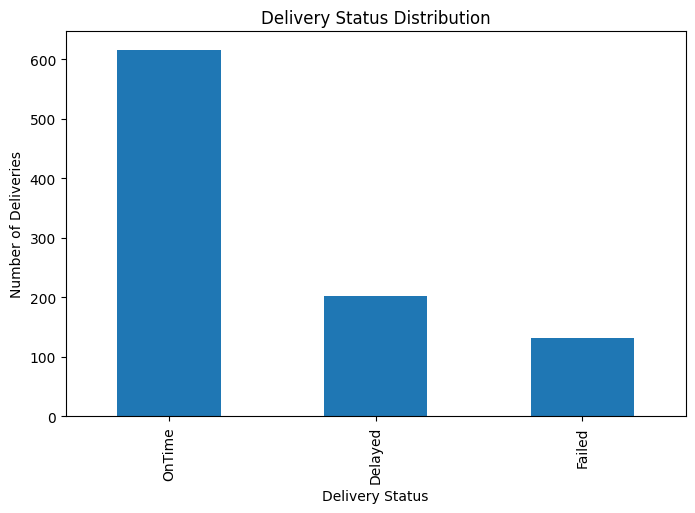

In [23]:
plt.figure(figsize=(8,5))
delivery_status_summary.plot(kind="bar")
plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Deliveries")
plt.show()

In [24]:
hub_analysis = deliveries.merge(hubs, on="hub_id", how="left")

hub_problem_summary = hub_analysis.groupby(["hub_name", "zone"]).agg(
    total_deliveries=("delivery_id", "count"),
    problem_deliveries=("is_problem_delivery", "sum"),
    average_rating=("customer_rating_post_delivery", "mean"),
    average_route_overrides=("manual_route_override_count", "mean")
).reset_index()

hub_problem_summary = hub_problem_summary.sort_values(by="problem_deliveries", ascending=False)

hub_problem_summary

,hub_name,zone,total_deliveries,problem_deliveries,average_rating,average_route_overrides
4,North Exchange,North,136,136,3.840593,1.029412
3,Midtown Relay,Central,128,128,3.884560,1.109375
7,West Gate,West,127,127,3.915476,0.874016
2,East Dock,East,119,119,3.895862,0.890756
5,Riverside Hub,Riverside,115,115,3.881858,1.052174
1,Central Core,Central,115,115,3.669558,0.947826
6,South Link,South,106,106,3.950952,0.915094
0,Airport Hub,Airport,104,104,3.882136,0.913462


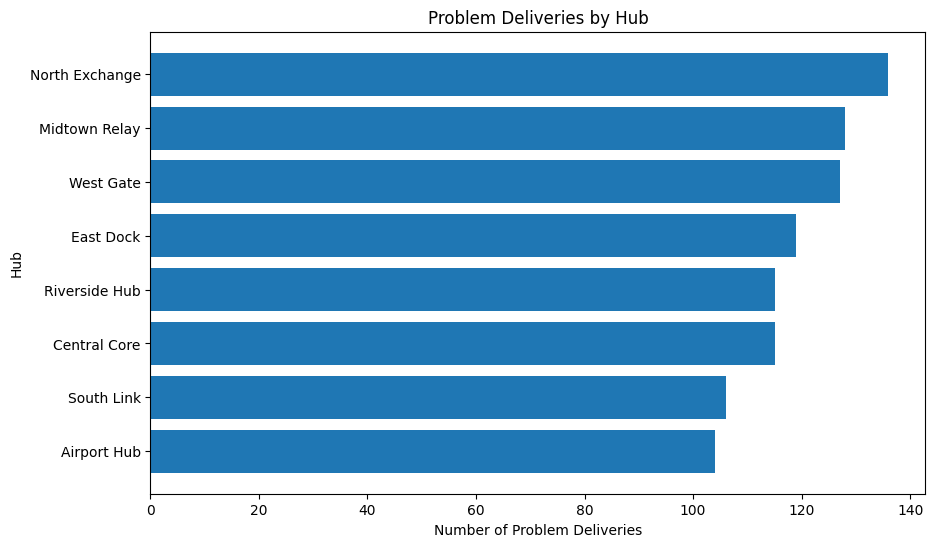

In [25]:
plt.figure(figsize=(10,6))
plt.barh(hub_problem_summary["hub_name"], hub_problem_summary["problem_deliveries"])
plt.title("Problem Deliveries by Hub")
plt.xlabel("Number of Problem Deliveries")
plt.ylabel("Hub")
plt.gca().invert_yaxis()
plt.show()

In [26]:
complaints_customer = complaints.merge(customers, on="customer_id", how="left")

complaints_by_type = complaints_customer.groupby("customer_type").size().reset_index(name="total_complaints")

complaints_by_type = complaints_by_type.sort_values(by="total_complaints", ascending=False)

complaints_by_type

,customer_type,total_complaints
0,Consumer,242
2,SME,50
1,Enterprise,28


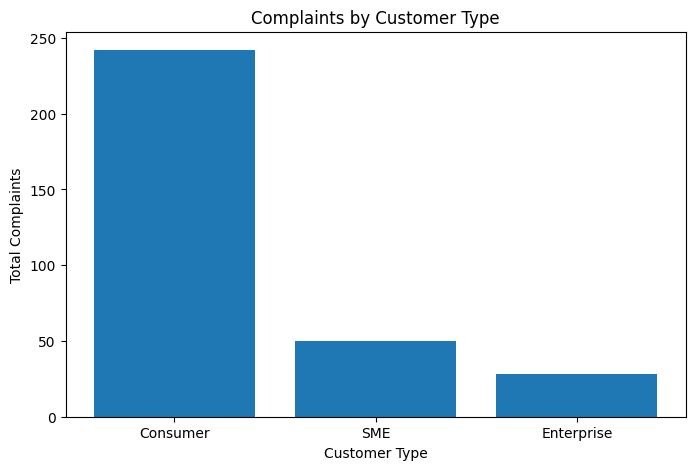

In [27]:
plt.figure(figsize=(8,5))
plt.bar(complaints_by_type["customer_type"], complaints_by_type["total_complaints"])
plt.title("Complaints by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Total Complaints")
plt.show()

In [28]:
complaints_by_zone = complaints_customer.groupby("home_zone").size().reset_index(name="total_complaints")

complaints_by_zone = complaints_by_zone.sort_values(by="total_complaints", ascending=False)

complaints_by_zone

,home_zone,total_complaints
11,SOUTH,33
2,CENTRAL,24
8,North,24
9,RiverSide,24
6,East,23
10,Riverside,21
15,north,21
7,NORTH,19
1,Airport,19
14,West,19


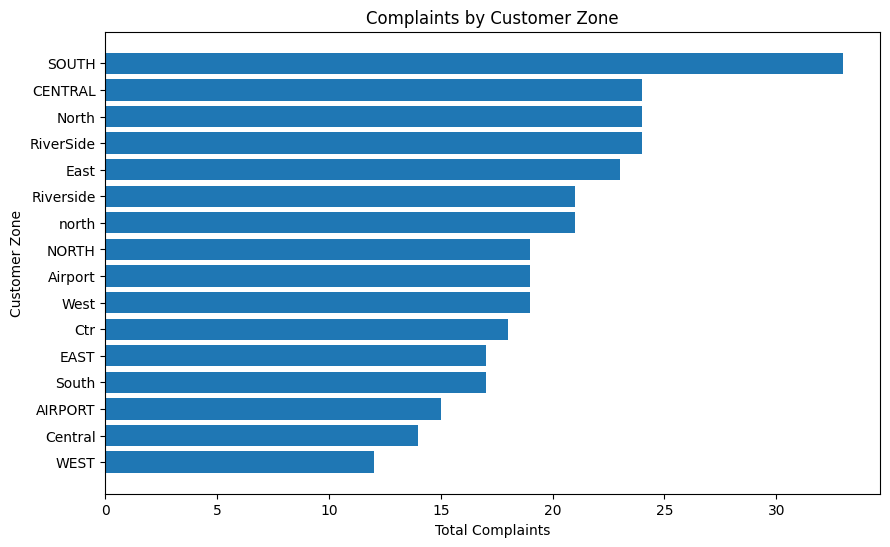

In [29]:
plt.figure(figsize=(10,6))
plt.barh(complaints_by_zone["home_zone"], complaints_by_zone["total_complaints"])
plt.title("Complaints by Customer Zone")
plt.xlabel("Total Complaints")
plt.ylabel("Customer Zone")
plt.gca().invert_yaxis()
plt.show()

In [30]:
route_override_summary = hub_analysis.groupby("hub_name").agg(
    total_route_overrides=("manual_route_override_count", "sum"),
    average_route_overrides=("manual_route_override_count", "mean")
).reset_index()

route_override_summary = route_override_summary.sort_values(by="total_route_overrides", ascending=False)

route_override_summary

,hub_name,total_route_overrides,average_route_overrides
3,Midtown Relay,142,1.109375
4,North Exchange,140,1.029412
5,Riverside Hub,121,1.052174
7,West Gate,111,0.874016
1,Central Core,109,0.947826
2,East Dock,106,0.890756
6,South Link,97,0.915094
0,Airport Hub,95,0.913462


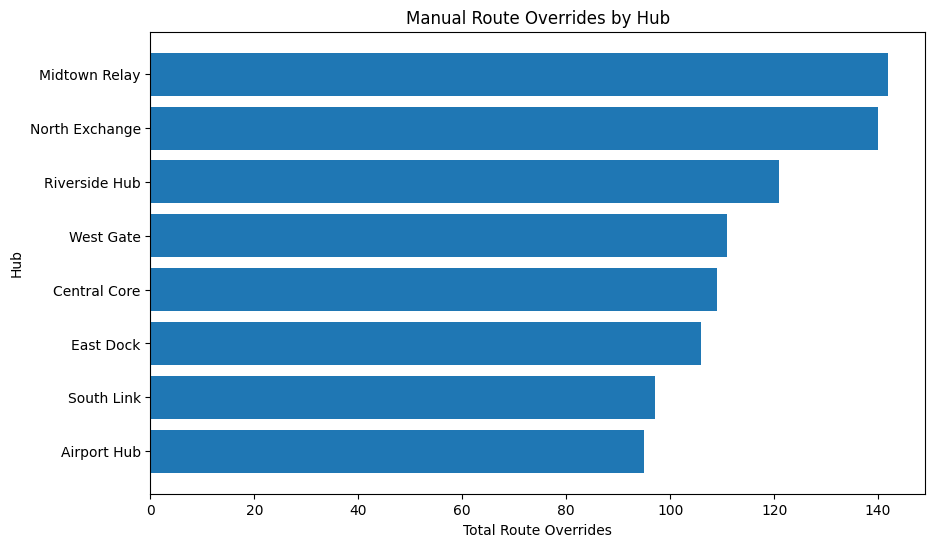

In [31]:
plt.figure(figsize=(10,6))
plt.barh(route_override_summary["hub_name"], route_override_summary["total_route_overrides"])
plt.title("Manual Route Overrides by Hub")
plt.xlabel("Total Route Overrides")
plt.ylabel("Hub")
plt.gca().invert_yaxis()
plt.show()

In [32]:
driver_incident_data = deliveries.merge(incidents, on="delivery_id", how="left")
driver_incident_data = driver_incident_data.merge(drivers, on="driver_id", how="left")

driver_incident_summary = driver_incident_data.groupby(
    ["driver_id", "base_zone", "employment_type", "training_score", "years_experience"]
).agg(
    total_incidents=("incident_id", lambda x: x.notna().sum())
).reset_index()

driver_incident_summary = driver_incident_summary.sort_values(by="total_incidents", ascending=False)

driver_incident_summary.head(10)

,driver_id,base_zone,employment_type,training_score,years_experience,total_incidents
36,D039,AIRPORT,Contract,86.1,7,7
82,D087,north,Contract,73.3,13,6
3,D004,Airport,PartTime,88.9,13,5
23,D026,NORTH,PartTime,84.9,4,5
126,D132,South,Contract,77.6,8,5
29,D032,East,PartTime,81.5,6,4
83,D088,Riverside,Contract,84.3,4,4
79,D084,Central,PartTime,47.2,2,4
34,D037,north,PartTime,63.9,7,4
89,D094,Ctr,PartTime,60.8,6,4


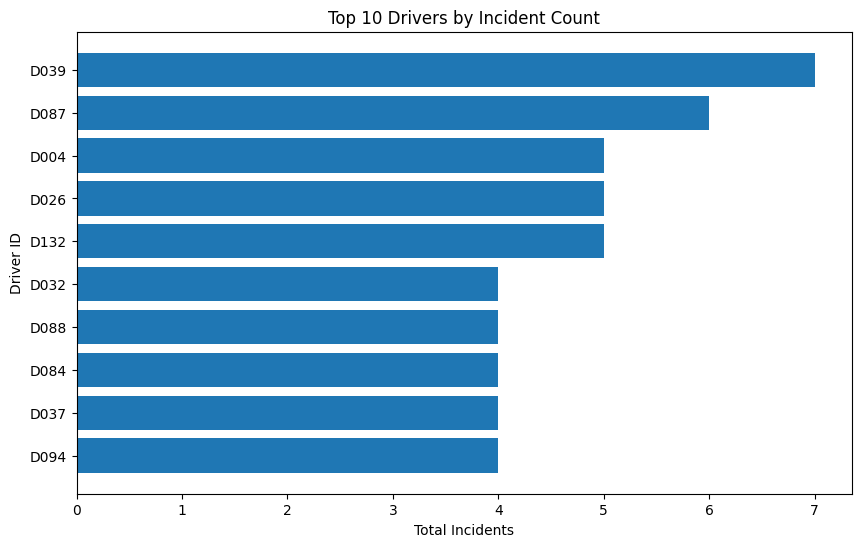

In [33]:
top_drivers = driver_incident_summary.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_drivers["driver_id"].astype(str), top_drivers["total_incidents"])
plt.title("Top 10 Drivers by Incident Count")
plt.xlabel("Total Incidents")
plt.ylabel("Driver ID")
plt.gca().invert_yaxis()
plt.show()

In [34]:
correlation_data = deliveries[
    [
        "customer_rating_post_delivery",
        "manual_route_override_count",
        "is_problem_delivery",
        "has_incident"
    ]
]

correlation_matrix = correlation_data.corr()

correlation_matrix

,customer_rating_post_delivery,manual_route_override_count,is_problem_delivery,has_incident
customer_rating_post_delivery,1.000000,-0.059903,NaN,0.010939
manual_route_override_count,-0.059903,1.000000,NaN,-0.088682
is_problem_delivery,NaN,NaN,NaN,NaN
has_incident,0.010939,-0.088682,NaN,1.000000


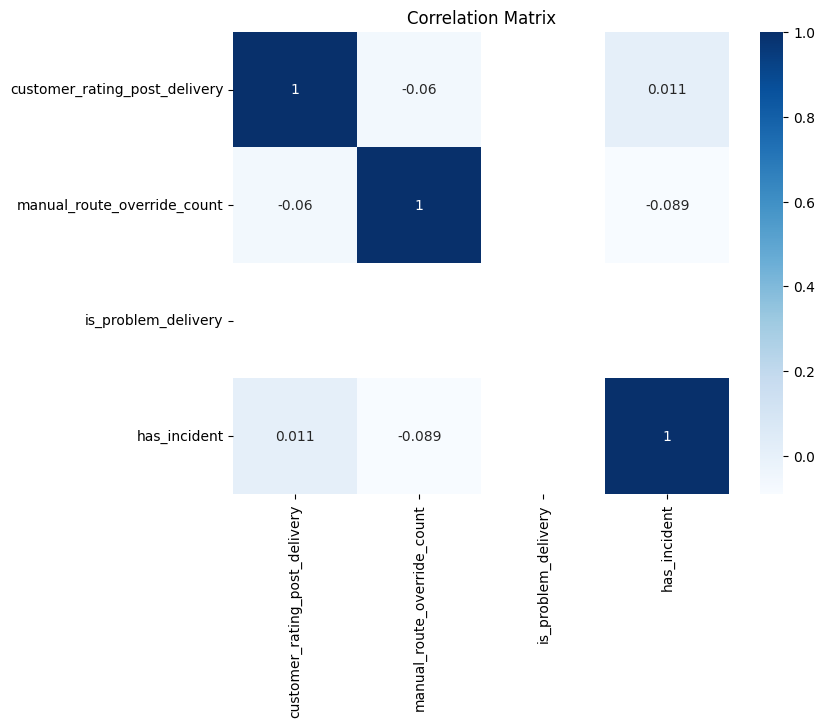

In [35]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [37]:
model_data = deliveries[
    [
        "customer_rating_post_delivery",
        "manual_route_override_count",
        "has_incident",
        "is_problem_delivery"
    ]
].dropna()

X = model_data[
    [
        "customer_rating_post_delivery",
        "manual_route_override_count",
        "has_incident"
    ]
]

y = model_data["is_problem_delivery"]

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [40]:
y_pred = model.predict(X_test)

y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [41]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Model Accuracy: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00       188

    accuracy                           1.00       188
   macro avg       1.00      1.00      1.00       188
weighted avg       1.00      1.00      1.00       188



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


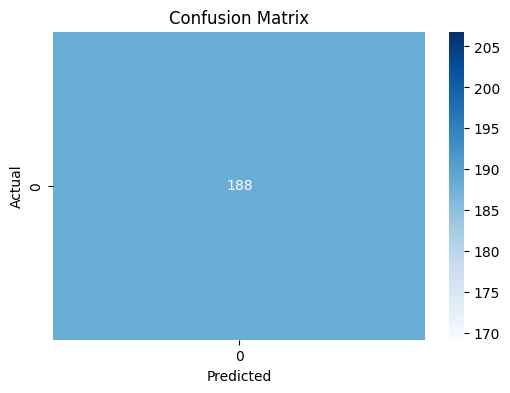

In [42]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [43]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance

,Feature,Importance
0,customer_rating_post_delivery,0.0
1,manual_route_override_count,0.0
2,has_incident,0.0


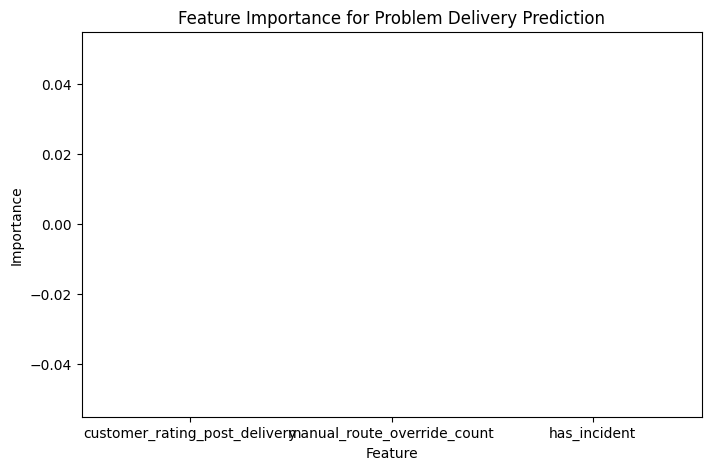

In [44]:
plt.figure(figsize=(8,5))
plt.bar(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Feature Importance for Problem Delivery Prediction")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.show()

In [45]:
deliveries.to_csv("processed_deliveries.csv", index=False)
customers.to_csv("processed_customers.csv", index=False)
hub_problem_summary.to_csv("python_hub_problem_summary.csv", index=False)
complaints_by_type.to_csv("python_complaints_by_type.csv", index=False)
complaints_by_zone.to_csv("python_complaints_by_zone.csv", index=False)
driver_incident_summary.to_csv("python_driver_incident_summary.csv", index=False)
feature_importance.to_csv("python_model_feature_importance.csv", index=False)

In [46]:
from google.colab import files

files.download("processed_deliveries.csv")
files.download("processed_customers.csv")
files.download("python_hub_problem_summary.csv")
files.download("python_model_feature_importance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>